In [ ]:
subset = DFCAT[(DFCAT["GAS"] == "Ar") & (DFCAT["TEMP"] == temp) & (DFCAT["LOW"] == 0.01)]
subset

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15,SAMPLING_SHORT
90,Ar,313,cat,qt_then_rd__cat,0.01,0.991559,0.967340,0.963651,0.000244,0.004825,...,2.904731,4.379958,5.360455,0.071018,0.134309,0.096533,struct+input,struct+input,struct+input,QT
91,Ar,313,cat,qt_then_rd__cat,0.05,0.994393,0.969743,0.964138,0.000567,0.001802,...,2.248791,4.067569,5.278337,0.024586,0.122536,0.071897,struct+input,struct+input,struct+input,QT
92,Ar,313,cat,qt_then_rd__cat,0.1,0.994223,0.968243,0.964872,0.000757,0.001890,...,2.042610,3.987635,5.271602,0.052916,0.031703,0.061486,struct+input,struct+input,struct+input,QT
93,Ar,313,cat,qt_then_rd__cat,0.5,0.996939,0.972230,0.967500,0.000158,0.003385,...,1.670383,3.697498,4.908584,0.068268,0.138443,0.063401,struct+input,struct+input,struct+input,QT
94,Ar,313,cat,qt_then_rd__cat,Henry,0.804611,0.910000,0.967090,0.038469,0.015570,...,6.309059,4.650251,4.655212,0.691621,0.198512,0.125771,struct+input,struct+input,struct+input,QT
95,Ar,313,cat,random_struct__cat,0.01,0.344041,0.480943,0.684833,0.054653,0.018571,...,54.518789,34.931408,23.559037,4.306835,1.482659,0.797157,struct,struct,struct,ST
96,Ar,313,cat,random_struct__cat,0.05,0.344041,0.480943,0.684833,0.054653,0.018571,...,54.518789,34.931408,23.559037,4.306835,1.482659,0.797157,struct,struct,struct,ST
97,Ar,313,cat,random_struct__cat,0.1,0.344041,0.480943,0.684833,0.054653,0.018571,...,54.518789,34.931408,23.559037,4.306835,1.482659,0.797157,struct,struct,struct,ST
98,Ar,313,cat,random_struct__cat,0.5,0.344041,0.480943,0.684833,0.054653,0.018571,...,54.518789,34.931408,23.559037,4.306835,1.482659,0.797157,struct,struct,struct,ST
99,Ar,313,cat,random_struct__cat,Henry,0.344041,0.480943,0.684833,0.054653,0.018571,...,54.518789,34.931408,23.559037,4.306835,1.482659,0.797157,struct,struct,struct,ST


C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_12600\2579849233.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")
C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_12600\2579849233.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFCAT["SAMPLING_SHORT"] = DFCAT["SAMPLING"].map(label_map)


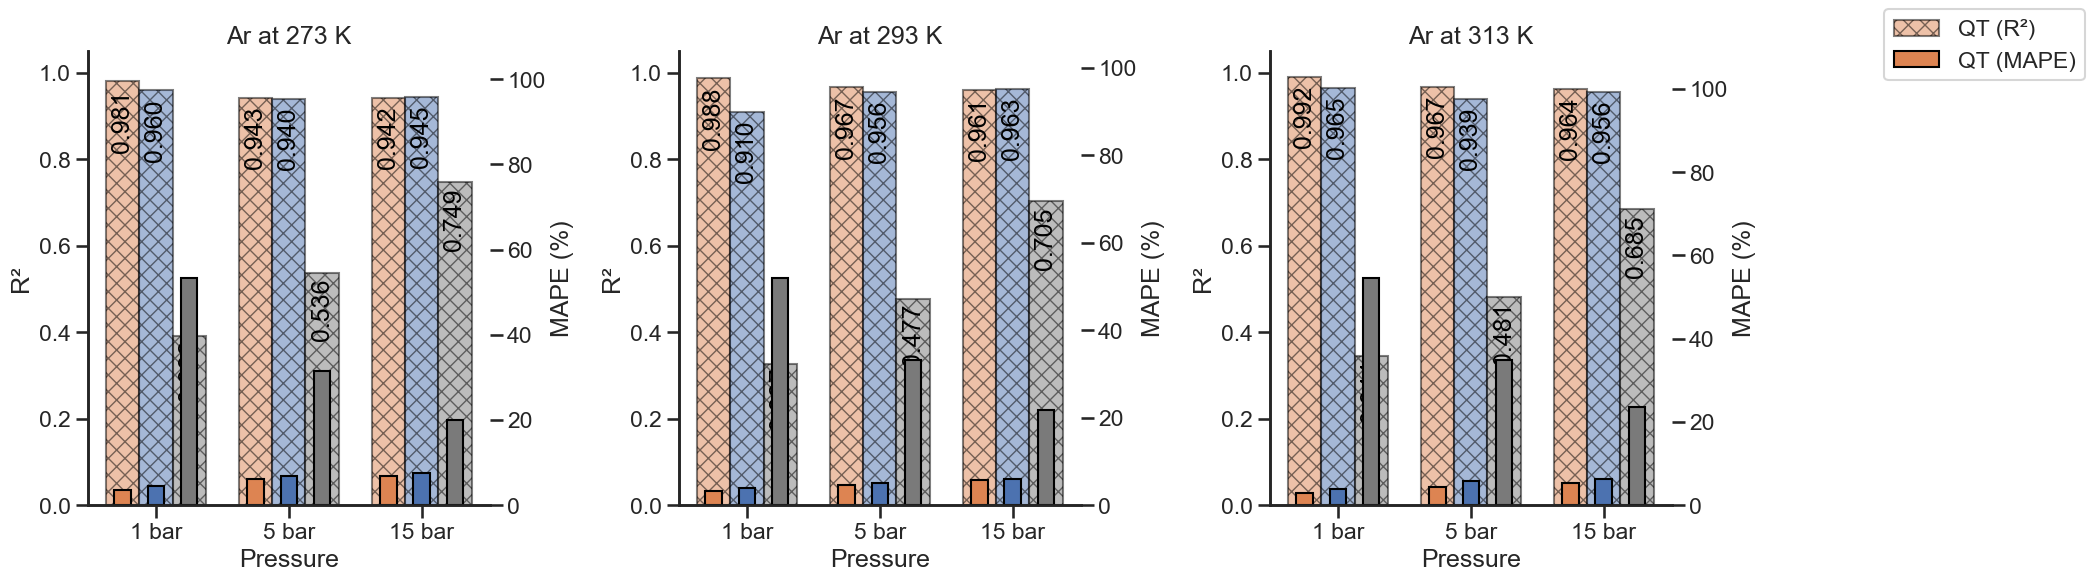

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Seaborn 스타일
sns.set_theme(style="ticks", context="talk")

# 데이터 로드
DF = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")
DFCAT = DF[DF["MODEL"] == "cat"]
DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")

# 샘플링 방식 매핑
label_map = {
    "random_struct__cat": "ST",
    "random_with_input__cat": "RD",
    "qt_then_rd__cat": "QT"
}
DFCAT["SAMPLING_SHORT"] = DFCAT["SAMPLING"].map(label_map)

# 색상 + 패턴 매핑
style_map = {
    "ST": {"color": "#7a7a7a", "hatch": "//"},   # 회색 + 사선 패턴
    "RD": {"color": "#4C72B0", "hatch": "xx"},   # 파랑 + 교차선
    "QT": {"color": "#DD8452", "hatch": ".."}    # 주황 + 점 패턴
}

# 압력별 컬럼 매핑 (R², MAPE 모두)
metrics_cols = {
    "1 bar": ("R2_MEAN_HIGH_1", "MAPE_MEAN_HIGH_1"),
    "5 bar": ("R2_MEAN_HIGH_5", "MAPE_MEAN_HIGH_5"),
    "15 bar": ("R2_MEAN_HIGH_15", "MAPE_MEAN_HIGH_15")
}

temps = [273, 293, 313]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

width = 0.25
handles, labels = [], []

for ax, temp in zip(axes, temps):
    subset = DFCAT[(DFCAT["GAS"] == "Ar") & (DFCAT["TEMP"] == temp) &   ]
    x = np.arange(len(metrics_cols))
    ax2 = ax.twinx()
    maxmape = 0

    for i, (samp, grp) in enumerate(subset.groupby("SAMPLING_SHORT")):
        r2_vals = [grp[r2_col].mean() for r2_col, _ in metrics_cols.values()]
        mape_vals = [grp[mape_col].mean() for _, mape_col in metrics_cols.values()]
        maxmape = max(maxmape, max(mape_vals))

        style = style_map[samp]

        # R² bar (밝은 색 + 공통 hatch = 격자무늬)
        bars_r2 = ax.bar(
            x + i*width, r2_vals, width,
            label=f"{samp} (R²)", color=style["color"],
            alpha=0.5, zorder=1, hatch="xx", edgecolor="black"  # ← 통일
        )


        # R² 값 표시
        for bar, val in zip(bars_r2, r2_vals):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height()*0.98,
                f"{val:.3f}",
                ha="center", va="top", rotation=90,
                fontsize=18, color="black"
            )

        # MAPE bar (짙은 색, hatch 제거 → 동일 색상만)
        bars_mape = ax2.bar(
            x + i*width, mape_vals, width*0.5,
            label=f"{samp} (MAPE)", color=style["color"],
            alpha=1.0, zorder=2, edgecolor="black"
        )

        if not handles:
            handles.extend([bars_r2, bars_mape])
            labels.extend([f"{samp} (R²)", f"{samp} (MAPE)"])

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_cols.keys())
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("R²")
    ax2.set_ylabel("MAPE (%)")
    ax2.set_ylim(0, maxmape*2)
    ax.set_title(f"Ar at {temp} K")
    ax.set_xlabel("Pressure")
    ax.grid(False)

# 범례
fig.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()  # 테두리도 깔끔하게
plt.tight_layout()
plt.show()


In [ ]:

DFCAT

In [37]:
DFCAT

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15,SAMPLING_SHORT
0,Ar,273,cat,qt_then_rd__cat,0.01,0.980530,0.942551,0.942233,0.001539,0.002202,...,3.604884,6.017872,6.906274,0.097235,0.173088,0.122752,struct+input,struct+input,struct+input,QT
1,Ar,273,cat,qt_then_rd__cat,0.05,0.981844,0.946434,0.947935,0.000772,0.002550,...,3.149899,5.811729,6.757988,0.097062,0.173467,0.146044,struct+input,struct+input,struct+input,QT
2,Ar,273,cat,qt_then_rd__cat,0.10,0.986484,0.950708,0.948975,0.002860,0.002741,...,2.959337,5.561020,6.672832,0.063514,0.145041,0.154566,struct+input,struct+input,struct+input,QT
3,Ar,273,cat,qt_then_rd__cat,0.50,0.995210,0.958574,0.949225,0.000432,0.003612,...,2.088218,5.123617,6.539972,0.029519,0.090167,0.121571,struct+input,struct+input,struct+input,QT
4,Ar,273,cat,random_struct__cat,0.01,0.392270,0.536265,0.748705,0.033201,0.029918,...,53.262373,31.425900,19.978451,3.763035,1.483399,0.753089,struct,struct,struct,ST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,N2,293,cat,random_struct__cat,0.01,NaN,0.375316,NaN,NaN,0.045065,...,NaN,32.384779,NaN,NaN,1.204254,NaN,NaN,struct,NaN,ST
221,N2,293,cat,random_with_input__cat,0.01,NaN,0.779396,NaN,NaN,0.084503,...,NaN,5.530313,NaN,NaN,0.484224,NaN,NaN,struct+input,NaN,RD
222,O2,293,cat,qt_then_rd__cat,0.01,NaN,0.970534,NaN,NaN,0.003469,...,NaN,4.245265,NaN,NaN,0.116166,NaN,NaN,struct+input,NaN,QT
223,O2,293,cat,random_struct__cat,0.01,NaN,0.384544,NaN,NaN,0.085843,...,NaN,32.443270,NaN,NaN,1.013727,NaN,NaN,struct,NaN,ST


C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_12600\152088199.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")
C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_12600\152088199.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFCAT["SAMPLING_SHORT"] = DFCAT["SAMPLING"].map(label_map)


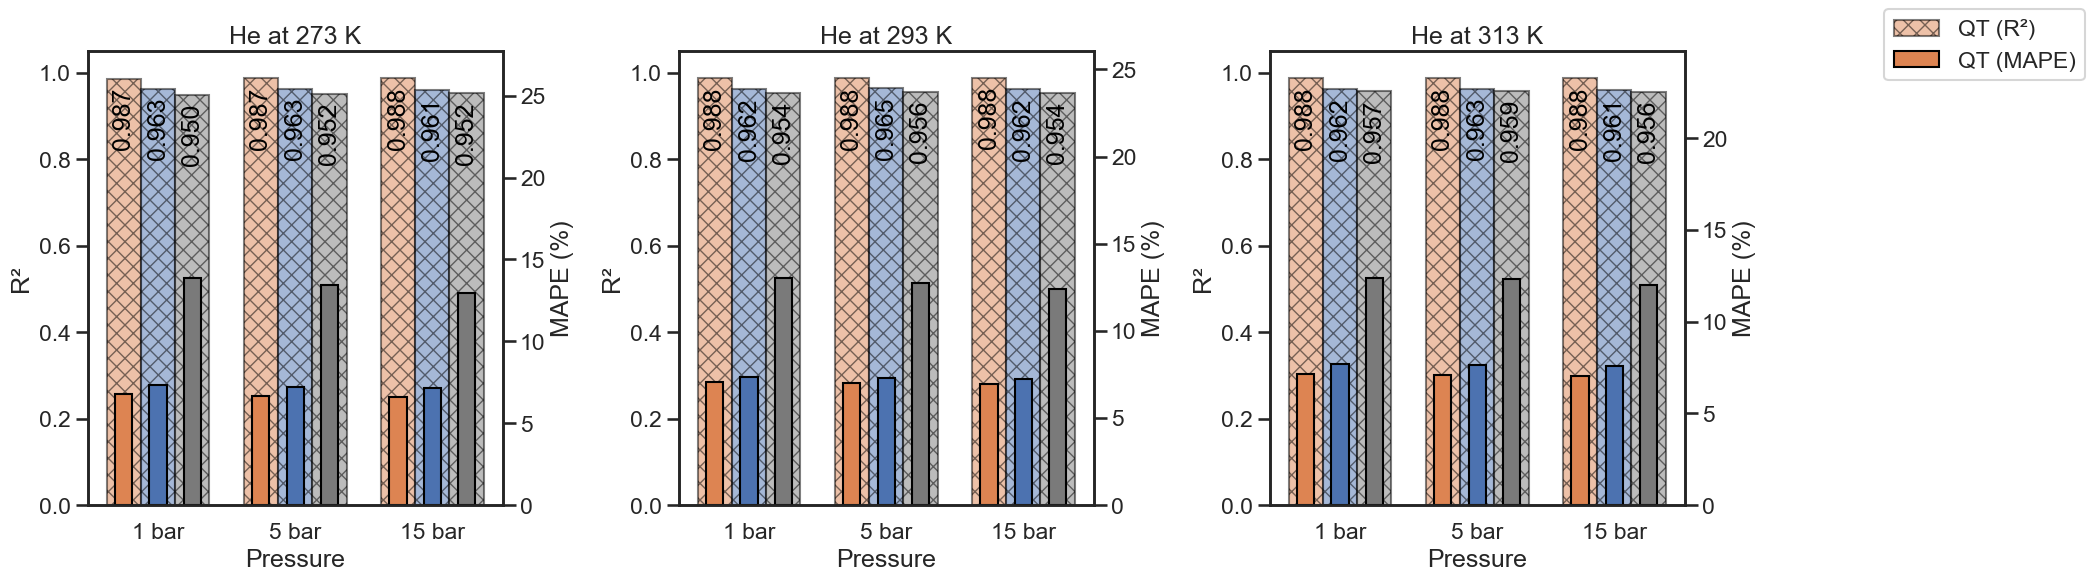

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
style_map = {
    "ST": {"color": "#7a7a7a", "hatch": "//"},   # 회색 + 사선 패턴
    "RD": {"color": "#4C72B0", "hatch": "xx"},   # 파랑 + 교차선
    "QT": {"color": "#DD8452", "hatch": ".."}    # 주황 + 점 패턴
}
# Seaborn 스타일
# sns.set_theme(style="whitegrid", context="talk")
sns.set_theme(style="white", context="talk")
# 데이터 로드
DF = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")
DFCAT = DF[DF["MODEL"] == "cat"]
DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")

# 샘플링 방식 매핑
label_map = {
    "random_struct__cat": "ST",
    "random_with_input__cat": "RD",
    "qt_then_rd__cat": "QT"
}
DFCAT["SAMPLING_SHORT"] = DFCAT["SAMPLING"].map(label_map)

# 색상 매핑 (QT 강조)
color_map = {
    "ST": "#7a7a7a",   # neutral gray
    "RD": "#4C72B0",   # blue
    "QT": "#DD8452"    # orange/red highlight
}

# 압력별 컬럼 매핑 (R², MAPE 모두)
metrics_cols = {
    "1 bar": ("R2_MEAN_HIGH_1", "MAPE_MEAN_HIGH_1"),
    "5 bar": ("R2_MEAN_HIGH_5", "MAPE_MEAN_HIGH_5"),
    "15 bar": ("R2_MEAN_HIGH_15", "MAPE_MEAN_HIGH_15")
}

temps = [273, 293, 313]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

width = 0.25

# 범례 핸들 저장용
handles, labels = [], []

for ax, temp in zip(axes, temps):
    subset = DFCAT[(DFCAT["GAS"] == "He") & (DFCAT["TEMP"] == temp) & (DFCAT["LOW"] == "0.01")]
    x = np.arange(len(metrics_cols))

    ax2 = ax.twinx()
    maxmape = 0

    for i, (samp, grp) in enumerate(subset.groupby("SAMPLING_SHORT")):
        r2_vals = [grp[r2_col].mean() for r2_col, _ in metrics_cols.values()]
        mape_vals = [grp[mape_col].mean() for _, mape_col in metrics_cols.values()]
        maxmape = max(maxmape, max(mape_vals))
        style = style_map[samp]

        # R² bar (밝은 색 + 공통 hatch = 격자무늬)
        bars_r2 = ax.bar(
            x + i*width, r2_vals, width,
            label=f"{samp} (R²)", color=style["color"],
            alpha=0.5, zorder=1, hatch="xx", edgecolor="black"  # ← 통일
        )


        # R² 값 표시
        for bar, val in zip(bars_r2, r2_vals):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height()*0.98,
                f"{val:.3f}",
                ha="center", va="top", rotation=90,
                fontsize=18, color="black"
            )

        # MAPE bar (짙은 색, hatch 제거 → 동일 색상만)
        bars_mape = ax2.bar(
            x + i*width, mape_vals, width*0.5,
            label=f"{samp} (MAPE)", color=style["color"],
            alpha=1.0, zorder=2, edgecolor="black"
        )

        # 범례 핸들 저장 (중복 제거)
        if not handles:
            handles.extend([bars_r2, bars_mape])
            labels.extend([f"{samp} (R²)", f"{samp} (MAPE)"])

    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_cols.keys())
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("R²")
    ax2.set_ylabel("MAPE (%)")
    ax2.set_ylim(0, maxmape * 2)
    ax.set_title(f"He at {temp} K")
    ax.set_xlabel("Pressure")
    # ax.grid(True, axis="y", linestyle="--", alpha=0.6, zorder=0)
    ax.grid(False)
# 범례는 전체 figure에 한 번만
fig.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
